In [5]:
import pandas as pd
import numpy as np

#Read the dataset safely
df = pd.read_csv("Online_Retail.csv", dtype=str)

# Display the first few rows of the dataframe
df.head()

# Display the data types of each column
df.dtypes

# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# display the shape of the dataframe
df.shape

Missing values in each column:
 InvoiceNo         0
StockCode         0
Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
dtype: int64


(541909, 8)

In [6]:
#CLEANING THE DATA
# Drop rows with missing values
#df = df.dropna(subset=['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'InvoiceDate'])
# Convert data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# display the shape of the dataframe
df.shape


(541909, 8)

In [7]:
# Transform Data Remove cancelled orders (InvoiceNo starts with 'C'), negative values
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# display the shape of the dataframe
df.shape
    

(530104, 8)

In [9]:
# Feature engineering
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df = df.dropna(subset=['CustomerID']) # For customer-level analysis

# display the shape of the dataframe
df.shape

(530104, 9)

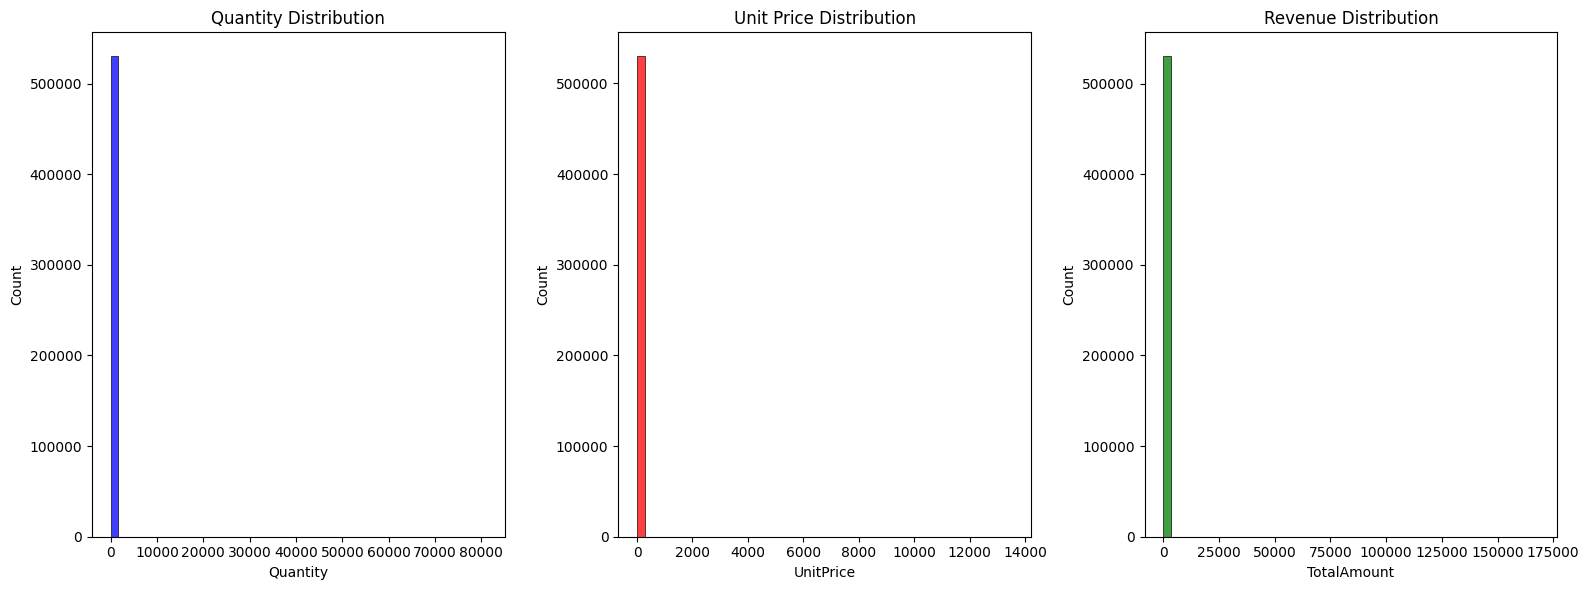

In [10]:

#Descriptive Statistics
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(16,6))
plt.subplot(1,3,1)
sns.histplot(df['Quantity'], bins=50, color='blue')
plt.title('Quantity Distribution')
plt.subplot(1,3,2)
sns.histplot(df['UnitPrice'], bins=50, color='red')
plt.title('Unit Price Distribution')
plt.subplot(1,3,3)
sns.histplot(df['TotalAmount'], bins=50, color='green')
plt.title('Revenue Distribution')
plt.tight_layout()
plt.show()

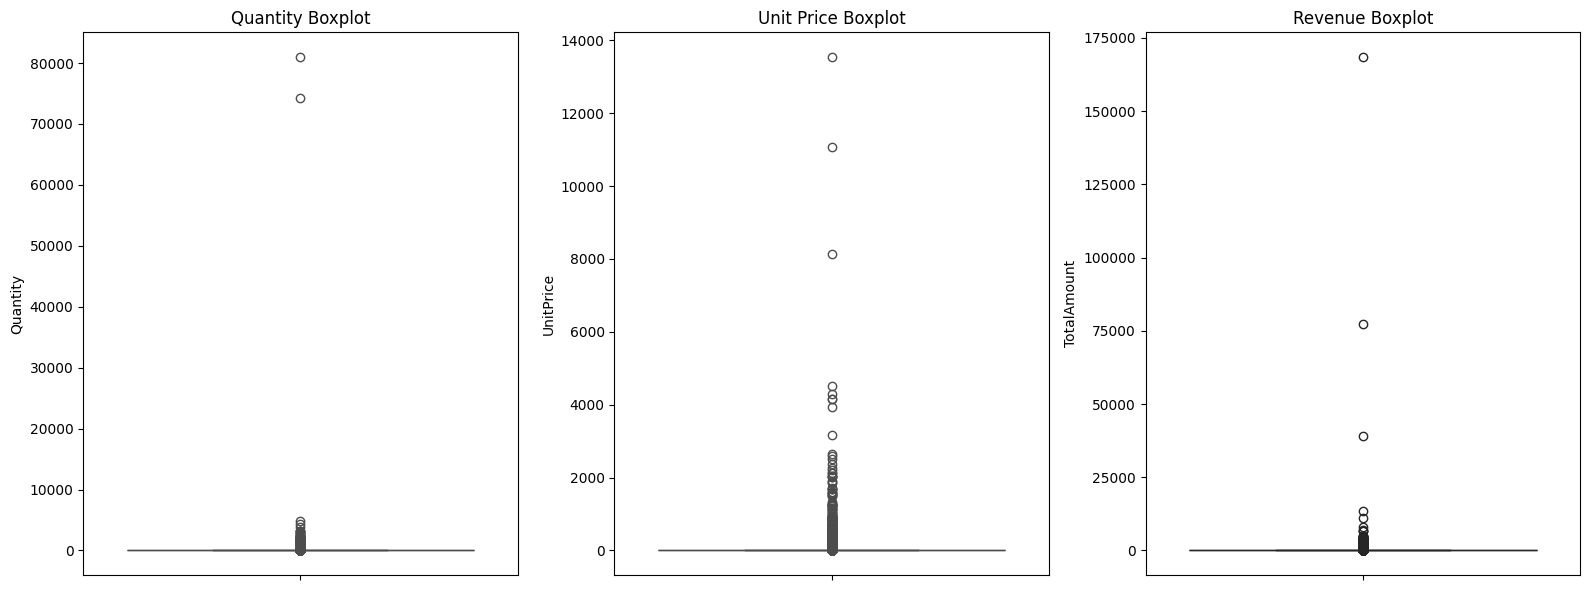

In [11]:
#Plot a blox plot for UnitPrice, qualtity and revenue
plt.figure(figsize=(16,6))
plt.subplot(1,3,1)
sns.boxplot(y=df['Quantity'], color='blue')
plt.title('Quantity Boxplot')
plt.subplot(1,3,2)
sns.boxplot(y=df['UnitPrice'], color='red')
plt.title('Unit Price Boxplot')
plt.subplot(1,3,3)
sns.boxplot(y=df['TotalAmount'], color='green')
plt.title('Revenue Boxplot')
plt.tight_layout()
plt.show()

The majority of transactions involve small quantities and low unit prices, but there are heavy outliers. Most revenue is from a small number of large-size purchases. This indicates a very skewed sales structure where a few sales dominate the business.

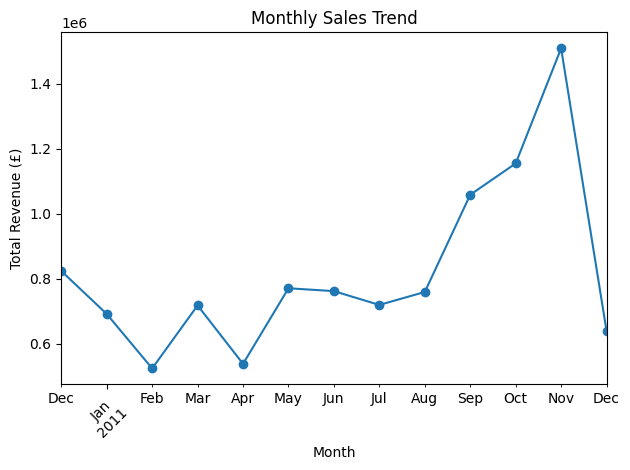

In [12]:
#Sales trend over time
import matplotlib.pyplot as plt

monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalAmount'].sum()
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Revenue (£)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales peak towards end-of-year, indicating strong holiday and seasonal effects. Business should focus marketing/promotions in these high-activity months.

In [ ]:
#Customer Analysis | Segmentation

def rfm_analysis(df):
    reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
    rfm = df.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (reference_date - x.max()).days,
        'InvoiceNo': 'nunique',
        'TotalAmount': 'sum'
    }).reset_index()
    rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
    return rfm

import plotly.express as px
import nbformat
rfm = rfm_analysis(df)
rfm['Segment'] = pd.qcut(rfm['Monetary'], 4, labels=['Low', 'Mid', 'High', 'Top'])
fig = px.scatter(rfm, x='Frequency', y='Monetary', color='Segment',
                 title='Customer Segmentation - RFM (Plotly Interactive)')

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

"Top" monetary customers are both highly active and have high spend. These are prime targets for loyalty programs and personalized offers. "Low" segment may need re-engagement strategies.

In [17]:
top_products = df.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)
fig = px.bar(top_products, x=top_products.index, y=top_products.values,
             labels={'x':'Product', 'y':'Revenue (£)'}, title='Top 10 Products by Revenue')
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

A small handful of products account for most sales. Stock and promotional focus should emphasize these core offerings.